# FAI Capstone Milestone 3
## K-Means Clustering: Experimental Study

**Group Members:** Parthiv Modi, Keshvi Choksi  
**Course:** CS5100 - Foundations of Artificial Intelligence  
**Instructor:** Jonathan Mwaura  

---

## Selected Paper
**MacQueen, J. (1967).** *Some Methods for Classification and Analysis of Multivariate Observations.*

## Additional Papers
- **Arthur, D. & Vassilvitskii, S. (2007).** *K-Means++: The Advantages of Careful Seeding.*
- **Rousseeuw, P. (1987).** *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis.*

---

## Project Goal
This project is based on MacQueen's K-means clustering method.  
We implement the core K-means logic from scratch and extend it using:
- Elbow Method
- Silhouette Analysis
- K-Means++ Initialization
- PCA Visualization

The goal is to study how K-means works in practice and how these extensions improve clustering analysis.

In [3]:
# -----------------------------------------
# IMPORTING REQUIRED LIBRARIES
# -----------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [4]:
# -----------------------------------------
# LOADING THE IRIS DATASET
# -----------------------------------------

iris = load_iris()
X = iris.data
y = iris.target

print("Dataset loaded successfully")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Dataset loaded successfully
Shape of X: (150, 4)
Shape of y: (150,)


In [5]:
# -----------------------------------------
# CONVERTING DATASET TO DATAFRAME
# -----------------------------------------

df = pd.DataFrame(X, columns=iris.feature_names)

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Why We Chose This Dataset

The original papers are mainly methodological and do not focus on a fixed dataset for implementation.

So, for this project, we use the **Iris dataset** from `sklearn.datasets`, because:
- it is a standard dataset for clustering
- it has 150 samples and 4 numerical features
- it has a clear structure that is suitable for K-means
- it is easy to analyze and visualize in a course project

We do **not** use the true labels to train K-means, because K-means is an unsupervised learning algorithm.  
The labels are only useful later for interpretation and visualization.

## Step 2: K-Means from Scratch

In this section, we are implementing the core K-means clustering logic from scratch.

### Main idea
1. Choosing initial centroids
2. Assigning each data point to the nearest centroid
3. Updating centroids using the mean of assigned points
4. Repeating until convergence

This follows the main clustering idea introduced in **MacQueen (1967)**.


In [6]:
# -----------------------------------------
# INITIALIZING CENTROIDS
# -----------------------------------------

def initialize_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

In [7]:
# -----------------------------------------
# ASSIGNING EACH POINT TO THE NEAREST CENTROID
# -----------------------------------------

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

In [8]:
# -----------------------------------------
# UPDATE CENTROIDS USING CLUSTER MEANS
# -----------------------------------------

def update_centroids(X, labels, k):
    centroids = []
    for i in range(k):
        cluster_points = X[labels == i]
        centroids.append(cluster_points.mean(axis=0))
    return np.array(centroids)

In [9]:
# -----------------------------------------
# FULL K-MEANS ALGORITHM (BATCH VERSION)
# -----------------------------------------

def kmeans_scratch(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)

    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

In [10]:
# -----------------------------------------
# RUN K-MEANS ON IRIS DATASET
# -----------------------------------------

k = 3
labels, centroids = kmeans_scratch(X, k)

print("K-means clustering completed successfully\n")
print("Final Centroids:")
print(centroids)

print("\nFirst 10 Cluster Assignments:")
print(labels[:10])

K-means clustering completed successfully

Final Centroids:
[[6.85       3.07368421 5.74210526 2.07105263]
 [5.006      3.428      1.462      0.246     ]
 [5.9016129  2.7483871  4.39354839 1.43387097]]

First 10 Cluster Assignments:
[1 1 1 1 1 1 1 1 1 1]


## Why This Step Matters

This is the core implementation of K-means.

### What is implemented here?
- random centroid initialization
- nearest-centroid assignment
- centroid update using means
- repeated iteration until convergence

### Connection to the paper
This reflects the main K-means idea from **MacQueen (1967)**:
- clusters are represented by means
- points are grouped based on nearest cluster center
- cluster centers are updated iteratively

## Step 3: Elbow Method (Choosing K)

The original K-means algorithm assumes that the number of clusters (K) is already known.

However, in practice, K is not always known in advance.

To address this, we use the **Elbow Method**, which helps estimate a suitable value of K.

### Idea:
- Run K-means for different values of K
- Compute the clustering error (inertia)
- Identify the point where improvement slows down (the "elbow")

In [11]:
# -----------------------------------------
# COMPUTING INERTIA (WITHIN-CLUSTER VARIATION)
# -----------------------------------------

def compute_inertia(X, labels, centroids):
    inertia = 0
    for i in range(len(X)):
        cluster_center = centroids[labels[i]]
        inertia += np.sum((X[i] - cluster_center) ** 2)
    return inertia

In [12]:
# -----------------------------------------
# RUNNING K-MEANS FOR DIFFERENT VALUES OF K
# -----------------------------------------

k_values = range(1, 11)
inertia_values = []

for k in k_values:
    labels, centroids = kmeans_scratch(X, k)
    inertia = compute_inertia(X, labels, centroids)
    inertia_values.append(inertia)

    print(f"K = {k}, Inertia = {inertia:.2f}")

K = 1, Inertia = 681.37
K = 2, Inertia = 152.35
K = 3, Inertia = 78.86
K = 4, Inertia = 71.45
K = 5, Inertia = 46.71
K = 6, Inertia = 47.96
K = 7, Inertia = 47.08
K = 8, Inertia = 42.75
K = 9, Inertia = 31.08
K = 10, Inertia = 30.67


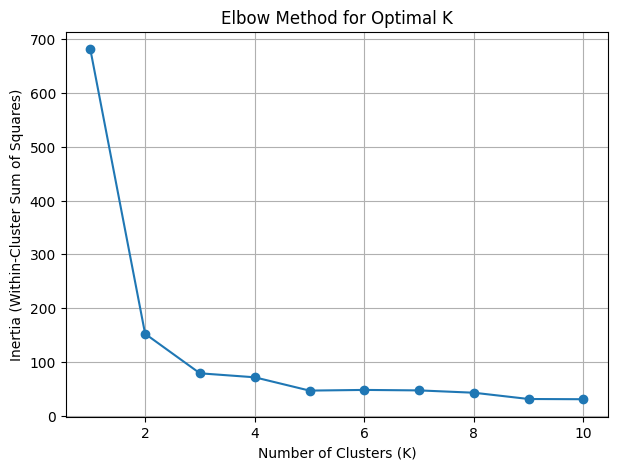

In [13]:
# -----------------------------------------
# PLOTTING ELBOW GRAPH
# -----------------------------------------

plt.figure(figsize=(7,5))
plt.plot(k_values, inertia_values, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")

plt.grid(True)
plt.show()

## Observation

We observe a sharp decrease in inertia initially, followed by a slower decrease.

This happens because:
- When K is small, many different points are forced into the same cluster
- This leads to high error (inertia)
- Increasing K allows better grouping, so error drops significantly

After a certain point, adding more clusters gives only small improvements.

This point is called the "elbow".

For the Iris dataset, the elbow appears around **K = 3**.

## Step 4: Silhouette Analysis (From Scratch)

To evaluate the quality of clustering, we implement **Silhouette Analysis** based on:

**Rousseeuw (1987)** - Silhouettes: A graphical aid to the interpretation of cluster analysis.

### Idea:
For each data point:
- Compute **a(i)** → average distance to points in the same cluster
- Compute **b(i)** → average distance to points in the nearest other cluster

Then:

s(i) = (b(i) - a(i)) / max(a(i), b(i))

The overall silhouette score is the average of s(i) across all points.

In [14]:
# -----------------------------------------
# COMPUTING SILHOUETTE SCORE FROM SCRATCH
# -----------------------------------------

def compute_silhouette_score(X, labels):
    n = len(X)
    silhouette_values = []

    for i in range(n):
        same_cluster = X[labels == labels[i]]
        other_clusters = [X[labels == l] for l in set(labels) if l != labels[i]]

        # a(i): average distance within same cluster
        if len(same_cluster) > 1:
            a_i = np.mean([np.linalg.norm(X[i] - x) for x in same_cluster if not np.array_equal(x, X[i])])
        else:
            a_i = 0

        # b(i): minimum average distance to other clusters
        b_i = float('inf')
        for cluster in other_clusters:
            distance = np.mean([np.linalg.norm(X[i] - x) for x in cluster])
            b_i = min(b_i, distance)

        # silhouette value
        if max(a_i, b_i) == 0:
            s_i = 0
        else:
            s_i = (b_i - a_i) / max(a_i, b_i)

        silhouette_values.append(s_i)

    return np.mean(silhouette_values)

In [15]:
# -----------------------------------------
# RUNNING SILHOUETTE FOR DIFFERENT K
# -----------------------------------------

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    labels, centroids = kmeans_scratch(X, k)
    score = compute_silhouette_score(X, labels)
    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.6810
K = 3, Silhouette Score = 0.5510
K = 4, Silhouette Score = 0.4952
K = 5, Silhouette Score = 0.3597
K = 6, Silhouette Score = 0.3652
K = 7, Silhouette Score = 0.3393
K = 8, Silhouette Score = 0.4328
K = 9, Silhouette Score = 0.2618
K = 10, Silhouette Score = 0.2750


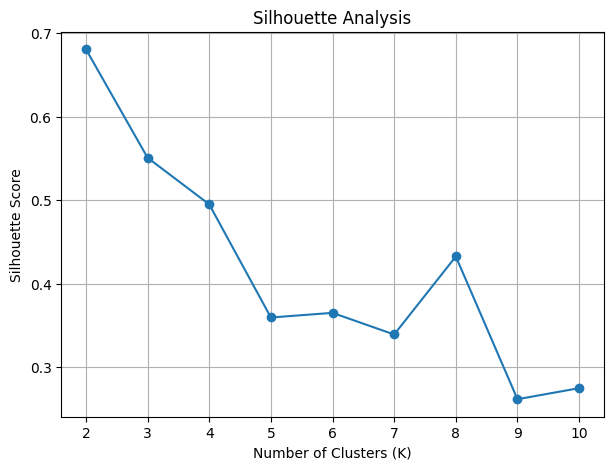

In [16]:
# -----------------------------------------
# PLOTTING SILHOUETTE GRAPH
# -----------------------------------------

plt.figure(figsize=(7,5))
plt.plot(k_values, silhouette_scores, marker='o')

plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.grid(True)
plt.show()

## Observation

We observe that the silhouette score is highest around **K = 2 or K = 3**.

### Interpretation:
- Higher score → better clustering
- Lower score → overlapping clusters

Since Elbow Method suggested K = 3, we select:

 Final K = 3

This balances both methods.

## Step 5: K-Means++ Initialization

Standard K-means uses random initialization, which can lead to poor clustering results.

To improve this, we use **K-Means++** based on:

**Arthur & Vassilvitskii (2007)**

### Idea:
- Choose first centroid randomly
- Choose next centroids based on distance from existing centroids
- Points farther away have higher probability

This helps spread centroids more effectively before clustering begins.

In [17]:
# -----------------------------------------
# K-MEANS++ INITIALIZATION
# -----------------------------------------

def initialize_centroids_kmeans_pp(X, k):
    n_samples = X.shape[0]
    centroids = []

    # Step 1: choose first centroid randomly
    first_idx = np.random.choice(n_samples)
    centroids.append(X[first_idx])

    # Step 2: choose remaining centroids
    for _ in range(1, k):
        distances = []

        for x in X:
            min_dist = min(np.sum((x - c) ** 2) for c in centroids)
            distances.append(min_dist)

        distances = np.array(distances)
        probabilities = distances / distances.sum()

        next_idx = np.random.choice(n_samples, p=probabilities)
        centroids.append(X[next_idx])

    return np.array(centroids)

In [18]:
# -----------------------------------------
# K-MEANS WITH K-MEANS++ INITIALIZATION
# -----------------------------------------

def kmeans_kpp(X, k, max_iters=100):
    centroids = initialize_centroids_kmeans_pp(X, k)

    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

In [19]:
# -----------------------------------------
# RUNNING K-MEANS++
# -----------------------------------------

k = 3
labels_kpp, centroids_kpp = kmeans_kpp(X, k)

print("K-Means++ clustering completed\n")
print("Centroids:")
print(centroids_kpp)



K-Means++ clustering completed

Centroids:
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


## Observation

K-Means++ produces more stable and consistent clustering results compared to random initialization.

This is because:
- centroids are more spread out initially
- reduces the chance of poor clustering

## Step 6: PCA Visualization

The Iris dataset has 4 features, so it is difficult to visualize directly.

To solve this, we use **Principal Component Analysis (PCA)** to reduce the data from 4 dimensions to 2 dimensions.

This allows us to:
- visualize clustering results
- interpret cluster separation
- compare clustering behavior

In [20]:
# -----------------------------------------
# APPLYING PCA (DIMENSION REDUCTION)
# -----------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (150, 4)
Reduced shape: (150, 2)


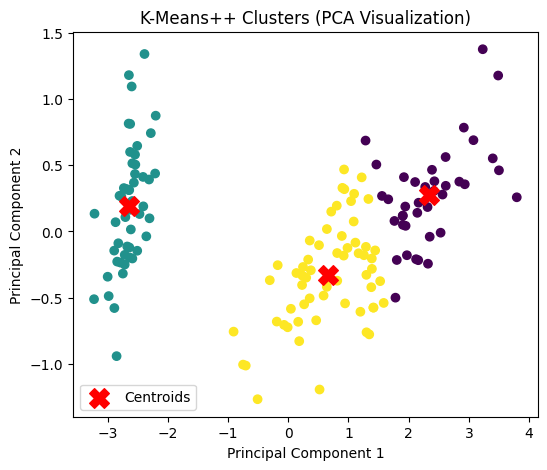

In [21]:
# -----------------------------------------
# VISUALIZING K-MEANS++ CLUSTERS
# -----------------------------------------

labels_kpp, centroids_kpp = kmeans_kpp(X, 3)

centroids_pca = pca.transform(centroids_kpp)

plt.figure(figsize=(6,5))

plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=labels_kpp,
            cmap='viridis')

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            color='red',
            marker='X',
            s=200,
            label='Centroids')

plt.title("K-Means++ Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

## Observation

The clusters are reasonably well separated in the 2D PCA space.

This shows that:
- K-means is able to group similar data points
- K-Means++ provides stable centroid placement

PCA helps us interpret clustering results visually.

## Final Summary

- K-means implemented from scratch (MacQueen, 1967)
- Elbow Method used to estimate K
- Silhouette Analysis used to validate clustering (Rousseeuw, 1987)
- K-Means++ improved initialization (Arthur & Vassilvitskii, 2007)
- PCA used for visualization

Final choice:
 K = 3

## Optional Extension: K-Median Clustering

In addition to K-means, we also implement **K-median clustering**.

### Main idea
K-median is similar to K-means, but instead of updating each cluster center using the **mean**, it uses the **median** of the points in that cluster.

### Why use K-median?
- More robust to outliers
- Less affected by extreme values
- Useful for comparing clustering behavior with K-means

### Difference from K-means
- **K-means** → centroid updated using mean
- **K-median** → centroid updated using median

In [22]:
# -----------------------------------------
# K-MEDIAN CLUSTERING FROM SCRATCH
# -----------------------------------------

def initialize_medians(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def assign_clusters_median(X, medians):
    distances = np.linalg.norm(X[:, np.newaxis] - medians, axis=2)
    return np.argmin(distances, axis=1)

def update_medians(X, labels, k):
    medians = []
    for i in range(k):
        cluster_points = X[labels == i]

        # Handle empty cluster safely
        if len(cluster_points) == 0:
            medians.append(X[np.random.choice(X.shape[0])])
        else:
            medians.append(np.median(cluster_points, axis=0))

    return np.array(medians)

def kmedian_scratch(X, k, max_iters=100):
    medians = initialize_medians(X, k)

    for _ in range(max_iters):
        labels = assign_clusters_median(X, medians)
        new_medians = update_medians(X, labels, k)

        if np.allclose(medians, new_medians):
            break

        medians = new_medians

    return labels, medians

In [23]:
# -----------------------------------------
# RUN K-MEDIAN CLUSTERING
# -----------------------------------------

k = 3
labels_kmedian, medians = kmedian_scratch(X, k)

print("K-Median clustering completed successfully\n")
print("Final Cluster Medians:")
print(medians)

print("\nFirst 10 Cluster Assignments:")
print(labels_kmedian[:10])

K-Median clustering completed successfully

Final Cluster Medians:
[[5.9 2.8 4.5 1.4]
 [5.  3.4 1.5 0.2]
 [6.7 3.  5.6 2.1]]

First 10 Cluster Assignments:
[1 1 1 1 1 1 1 1 1 1]


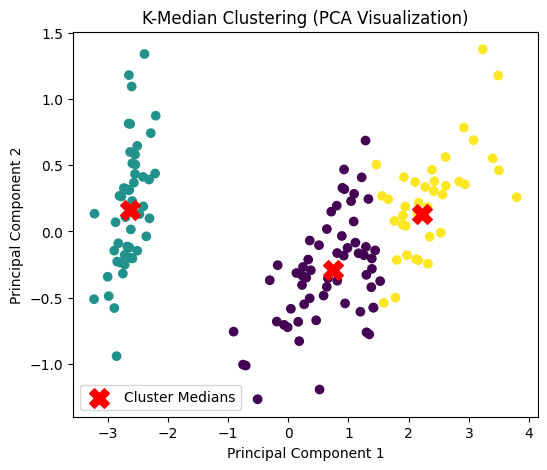

In [24]:
# -----------------------------------------
# VISUALIZE K-MEDIAN CLUSTERS USING PCA
# -----------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
medians_pca = pca.transform(medians)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmedian, cmap='viridis')

plt.scatter(medians_pca[:, 0], medians_pca[:, 1],
            color='red', marker='X', s=200, label='Cluster Medians')

plt.title("K-Median Clustering (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

## Observation

K-median clustering groups the data in a similar way to K-means, but the cluster centers are computed using the **median** instead of the **mean**.

This makes K-median:
- less sensitive to outliers
- useful as a comparison method
- helpful for understanding how center choice affects clustering